In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")

In [3]:
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [5]:
train['Driver'].nunique()

887

In [6]:
train['Race'].nunique()

26

In [7]:
train['Year'].unique()

array([2022, 2025, 2023, 2024])

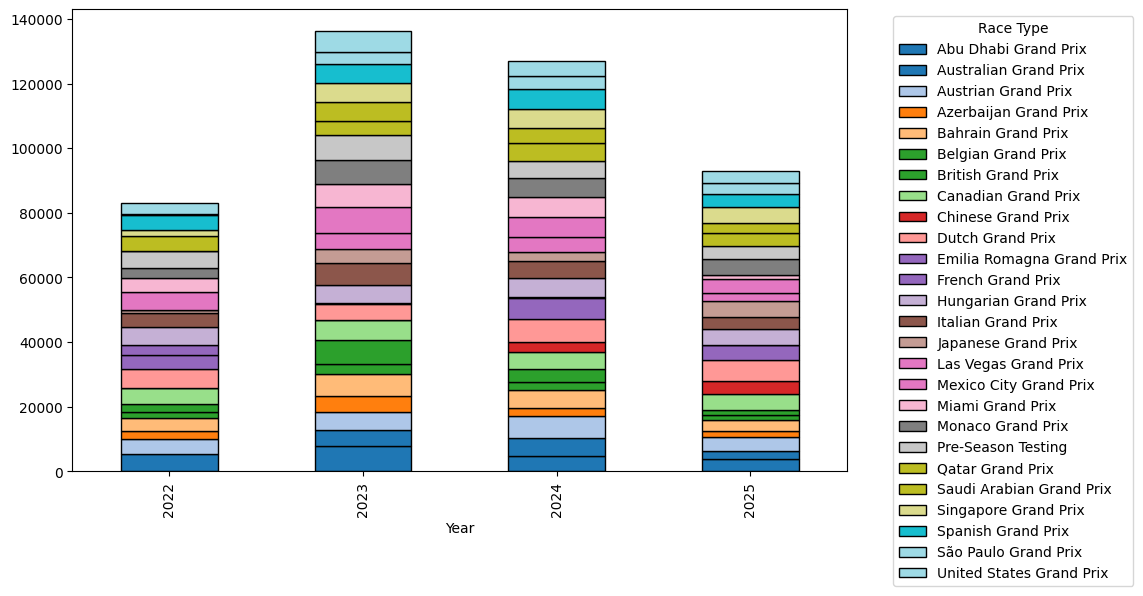

In [8]:
race_year_matrix = pd.crosstab(train['Year'],train['Race'])

race_year_matrix.plot(kind='bar', stacked=True, edgecolor='black', colormap='tab20', figsize=(10, 6))

plt.legend(title='Race Type', bbox_to_anchor=(1.05, 1), loc='upper left')

In [9]:
race_counts = (
    train.groupby(['Year', 'Race'])
        .size()
        .reset_index(name='count')
      
)

top_races_per_year = (
    race_counts.sort_values(['Year','count'],ascending=[True,False])
        .groupby("Year")
        .head()
        .reset_index(drop=True)
        
)

top_races_per_year['Year'] = top_races_per_year['Year'].astype('object')



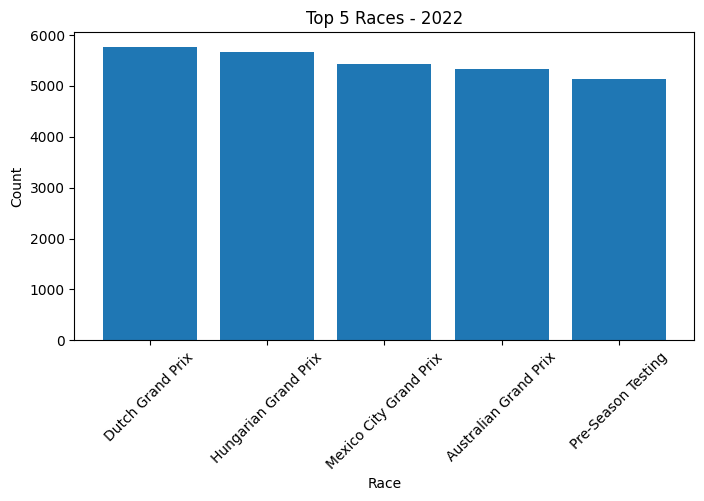

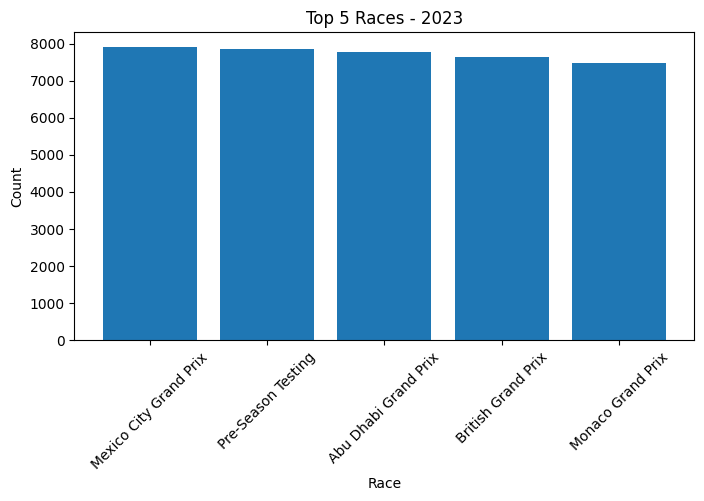

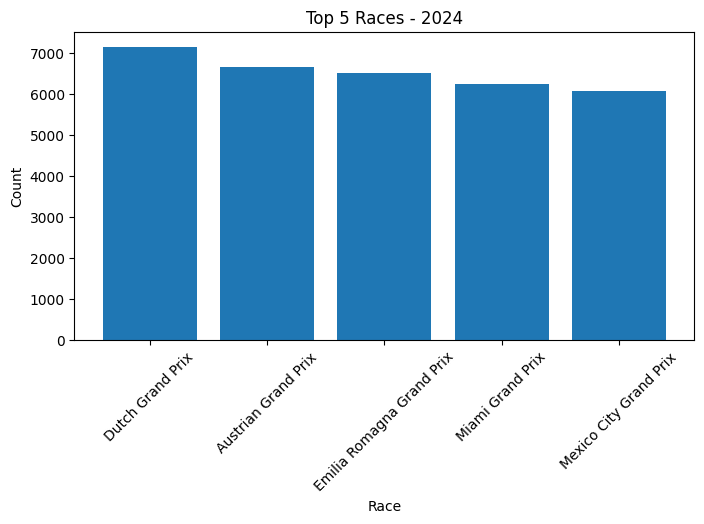

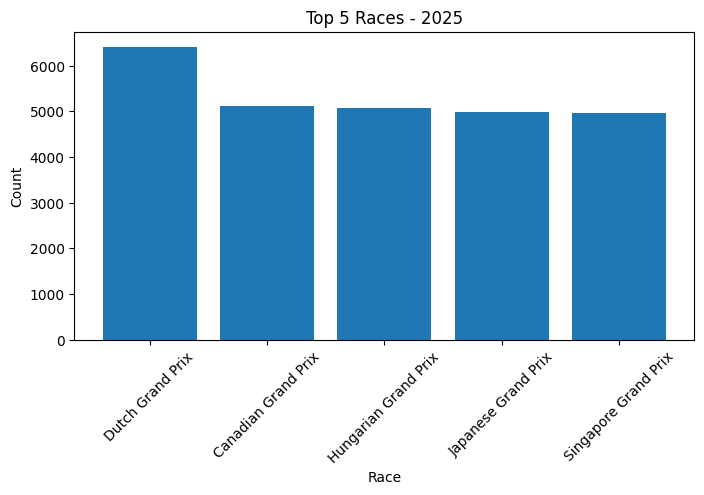

In [10]:
for year, data in top_races_per_year.groupby('Year'):
    plt.figure(figsize=(8, 4))

    plt.bar(data['Race'], data['count'])

    plt.title(f"Top 5 Races - {year}")
    plt.xlabel("Race")
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

In [11]:
train['PitNextLap'].value_counts(normalize=True)


PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64

In [12]:
train.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')

In [13]:
cat_cols = ['Compound', 'Race']

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

In [14]:
X = train.drop(['id', 'Driver','PitNextLap'],axis=1)
Y = train['PitNextLap']

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [16]:
model = LogisticRegression(max_iter=5000,verbose=1)
model.fit(X_train,Y_train)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  4.1min finished


LogisticRegression(max_iter=5000, verbose=1)

In [17]:
preds = model.predict(X_test)

In [18]:
print("f1_score",f1_score(preds,Y_test))
print("precision_score",precision_score(preds,Y_test))
print("recall_score",recall_score(preds,Y_test))
print("roc_auc_score",roc_auc_score(preds,Y_test))


f1_score 0.42353834472285495
precision_score 0.31797970584881996
recall_score 0.6340077290293249
roc_auc_score 0.7413110896190532


In [19]:
predictions = model.predict(test.drop(['id','Driver'],axis=1))

In [20]:
submission = pd.DataFrame({
    'id':test['id'],
    'PitNextLap':predictions
})

submission.to_csv("submission.csv",header=True)